# BTK Datathon 2026 Çözüm Defteri

> **🏆 SONUÇ, Private #4 / 579, MSE 81.6322** (`SUB_qpfinal`).
> Final-snapshot public #15'ten private #4'e (+11 sıra). Sahanın ortalama public'ten private'a kayma **+0.74** iken
> bizimki **+0.42**, public'i ezberlemeyen temiz model gizli kümede daha sağlam kaldı (§9).

**Görev:** `career_success_score` (0–100) tahmini, **Metrik:** MSE, **Veri:** 10.000 train / 10.000 test satırı,
45 sütun + Türkçe `mentor_feedback_text`

Bu defter, çözümün uçtan uca hikâyesini ve her iddianın **doğrulanabilir kanıtını** sunar:

| Bölüm | İçerik |
|---|---|
| 1 | EDA, verinin sentetik yapısının ilk işaretleri |
| 2 | **Veri üretecinin tersine mühendisliği**, ondalık-hassasiyet parmak izi (çözümün ayırt edici buluşu) |
| 3 | Özellik mühendisliği, üreteç bilgisine dayalı bloklar |
| 4 | Metin üyeleri, Türkçe mentor yorumlarından fine-tune edilmiş transformer regresörleri |
| 5 | Stack, çok-aileli iki seviyeli ansambl (GBDT + metin + **TabPFN-v2 + kernel-ridge + kNN-feat**) |
| 6 | Kalibrasyon & harman, kesin MSE özdeşliği ve moment kalibrasyonu (öngörü hatası 0.002–0.006) |
| 7 | Doğrulama felsefesi, neyin gerçekten transfer ettiğini board kanıtlarıyla öğrenme süreci |
| 8 | Sonuç ve final seçimi, final-2 ve private #4 |
| 9 | **Private sonuç & shake doğrulaması**, temiz modelin shake'te öne çıkması, kalibrasyonun private'a transferi |

**Bu repo ve çalıştırma notu:** Bu paylaşılan repo, çözümün anlatısını içeren bu tek defterden oluşur; çıktıları gömülü olduğu için çalıştırmadan baştan sona okunabilir. Metinde geçen `src/...`, `reports/...`, `kernels/...`, `submissions/frozen/` yolları ve `docs/SUBMISSIONS_LOG.md`, çözümün tam proje deposundaki dosyalara yapılan izlenebilirlik (provenance) referanslarıdır; her adımın hangi script ve çıktıyla üretildiğini gösterirler, bu özette ayrıca yer almazlar. Ağır eğitim adımları (GPU'da fine-tune edilen transformer'lar, Optuna taramaları) burada yeniden eğitilmez; o hücreler kayıtlı çıktıları yükler.


## 0. Kurulum

Aşağıdaki hücreler, çözümün tam proje deposundaki kayıtlı artefaktları kullanır: üye OOF/test tahminleri `reports/*_member_{oof,test}.npy`, GBDT üçlüsü `reports/tuned_*`, board CSV'leri `submissions/frozen/`. Bu paylaşılan özette o artefaktlar bulunmaz; defter **gömülü çıktılarıyla** okunmak üzere hazırlanmıştır.


In [1]:
import json, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

# repo yerlesimi: <root>/data/raw, <root>/reports, <root>/src, <root>/submissions/frozen
ROOT = Path.cwd()
if not (ROOT / "data" / "raw" / "train.csv").exists():
    for cand in (ROOT.parent, ROOT / "2026", ROOT.parent / "2026"):
        if (cand / "data" / "raw" / "train.csv").exists():
            ROOT = cand
            break
RAW, REP, FROZEN = ROOT / "data" / "raw", ROOT / "reports", ROOT / "submissions" / "frozen"
sys.path.insert(0, str(ROOT / "src"))

TARGET, YEAR, TEXT = "career_success_score", "application_year", "mentor_feedback_text"
LO, HI = 0.0, 100.0

train = pd.read_csv(RAW / "train.csv", low_memory=False)
test = pd.read_csv(RAW / "test_x.csv", low_memory=False)
y = train[TARGET].to_numpy(float)
print(f"train {train.shape} · test {test.shape}")

train (10000, 47) · test (10000, 46)


## 1. Keşifsel Veri Analizi

Dört bulgu bütün stratejiyi belirledi:

1. **Hedef [0, 100] aralığına kırpılmış:** satırların **%7.73'ü tam 100.0** (sağ-sansür yığılması), tek bir 0 var.
   Bu, üretecin gizli skoru 100'de kestiğinin ilk işareti, §2'de mekanizma olarak geri dönecek.
2. **`application_year` 2019–2026**, train'de dengeli; **test güncel-yıl ağırlıklı: 2024–26 payı %62.2**
   (train'de %35). Değerlendirme örtük olarak güncel yılları ağırlıklandırıyor, dolayısıyla doğrulama tasarımını
   (forward-year CV, test-yıl-ağırlıklı OOF) doğrudan bu belirledi.
3. **Hedefin yıl içi standart sapması 12.6'dan (2019) 18.0'e (2026) büyüyor**, indirgenemez gürültü zamanla
   artıyor. Test güncel-yıl ağırlıklı olduğu için ulaşılabilir skor tabanı da buna göre yüksek.
4. **`mentor_feedback_text` (Türkçe) gizli skoru sözelleştiriyor:** metin, sayısal kolonlardan *üretilmiş*
   şablonlu bir özet ve hedef seviyesini açıkça anlatıyor ("mükemmel bir başarı skoru" ↔ y≈100).
   Bu kolon yarışmanın en büyük tekil sinyal kaynağı çıktı (§4).

count    10000.00
mean        76.94
std         15.19
min          0.00
25%         66.94
50%         77.81
75%         88.47
max        100.00
Name: career_success_score, dtype: float64

tam 100.0 olan satir orani: %7.73  (sag-sansur)
tam 0.0 olan satir sayisi: 1


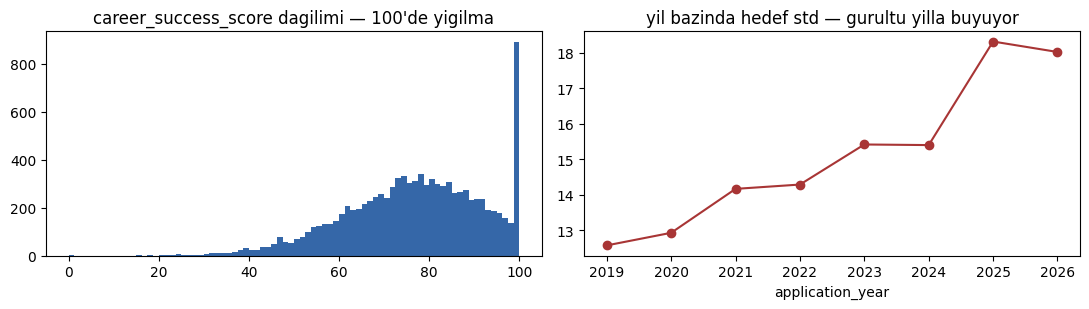

In [2]:
print(train[TARGET].describe().round(2))
print(f"\ntam 100.0 olan satir orani: %{(y == 100).mean() * 100:.2f}  (sag-sansur)")
print(f"tam 0.0 olan satir sayisi: {(y == 0).sum()}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(y, bins=80, color="#3567a8")
ax[0].set_title("career_success_score dagilimi — 100'de yigilma")
sd = train.groupby(YEAR)[TARGET].std()
ax[1].plot(sd.index, sd.values, "o-", color="#a83535")
ax[1].set_title("yil bazinda hedef std — gurultu yilla buyuyor")
ax[1].set_xlabel("application_year")
plt.tight_layout(); plt.show()

In [3]:
mix = pd.DataFrame({
    "train %": train[YEAR].value_counts(normalize=True).sort_index() * 100,
    "test %":  test[YEAR].value_counts(normalize=True).sort_index() * 100,
}).round(1)
print(mix)
print(f"\ntest 2024-26 payi: %{test[YEAR].isin([2024, 2025, 2026]).mean() * 100:.1f}"
      f"   (train: %{train[YEAR].isin([2024, 2025, 2026]).mean() * 100:.1f})")

                  train %  test %
application_year                 
2019                 12.9     4.0
2020                 13.3     5.1
2021                 12.7     6.9
2022                 12.9     8.8
2023                 13.1    13.0
2024                 13.2    19.9
2025                 11.9    22.0
2026                 10.0    20.3

test 2024-26 payi: %62.2   (train: %35.1)


### Metin kolonu: üreteç hedefi sözelleştiriyor

Mentor yorumları şablonlu ve *skorlardan üretilmiş*: güçlü beceriler övülüyor, zayıflar "geliştirmesi gerekir"
kalıbıyla anılıyor ve hedefin genel seviyesi açıkça söyleniyor. Basit bir Türkçe leksikon polaritesi bile hedefle
0.39 korelasyon veriyor; bu gözlem 1. gün board'da test edildi (−1.37 MSE) ve metin hattının tamamını başlattı.

In [4]:
import features as F  # src/features.py — uretim feature modulu

hi_txt = train.loc[train[TARGET] >= 99, TEXT].iloc[0]
lo_txt = train.loc[train[TARGET] <= 40, TEXT].iloc[0]
print("y>=99 ornegi:\n ", hi_txt[:350], "\n")
print("y<=40 ornegi:\n ", lo_txt[:350])

pol = F._text_polarity(train[TEXT].tolist())
print(f"\nbasit Turkce leksikon polaritesi <-> hedef korelasyonu: {np.corrcoef(pol, y)[0, 1]:.3f}")

y>=99 ornegi:
  Mükemmel bir kariyer skoruna sahip olman, teknik becerilerinin yanı sıra güçlü iletişim yeteneklerinle de birleşiyor. Cybersecurity alanında gösterdiğin ilerleme ve müşteri projelerinde edindiğin deneyimler, seni bu alanda oldukça donanımlı bir aday yapıyor. 

y<=40 ornegi:
  Öğrencinin Frontend geliştirme yetenekleri oldukça güçlü, özellikle yüksek frontend skoru dikkat çekiyor. Ancak, projelerinin kalitesi ve sunum yetenekleri üzerinde çalışması gerektiği gözlemleniyor. İletişim becerilerini geliştirmesi kariyer yolculuğunda önemli bir adım olacaktır.

basit Turkce leksikon polaritesi <-> hedef korelasyonu: 0.387


## 2. Veri Üretecinin Tersine Mühendisliği

**Çözümün ayırt edici buluşu.** Veri sentetik; sentetik veri üreteci ise iz bırakır. Kolon kolon ondalık-hassasiyet
taraması (`src/38_column_probe.py`, `src/45_forensics_deep.py`) şunu gösterdi:

> Beceri skorlarının neredeyse tamamı **tam 2 ondalık** basamaklı. Ama **6 kolonda** (`sql`, `machine_learning`,
> `backend`, `frontend`, `cloud`, `devops`) satırların %15–40'ında **tam-hassasiyetli float'lar** var
> (örn. `63.0418967196188`) ve bu desen `target_role`'a göre **~%97 deterministik**.

Mekanizma hipotezi: üreteç önce taban becerileri çekip 2 ondalığa yuvarlıyor; sonra rolün **çekirdek
becerilerine sürekli (yuvarlanmamış) bir rol-uyum boost'u ekliyor**. Toplam, tam-hassasiyetli float olarak
kalıyor, parmak izi tam da bu. Aşağıdaki çapraz tablo deseni çıplak gözle gösteriyor.

In [5]:
HIDEC = ["sql_score", "machine_learning_score", "backend_score",
         "frontend_score", "cloud_score", "devops_score"]
hd = pd.DataFrame({c: ((train[c].round(2) != train[c]) & train[c].notna()) for c in HIDEC})
hd["target_role"] = train["target_role"]
print("tam-hassasiyetli (boost'lu) hucre orani %, rol bazinda:")
print((hd.groupby("target_role").mean() * 100).round(1))

tam-hassasiyetli (boost'lu) hucre orani %, rol bazinda:


                       sql_score  machine_learning_score  backend_score  frontend_score  cloud_score  devops_score
target_role                                                                                                       
AI Engineer                  0.0                    96.7            0.0             0.0          0.0           0.0
Backend Developer           97.3                     0.0           95.3             0.0          0.0           0.0
Cloud Engineer               0.0                     0.0            0.0             0.0         97.0          97.4
Cybersecurity Analyst        0.0                     0.0            0.0             0.0          0.0           0.0
Data Analyst                94.4                    97.5            0.0             0.0          0.0           0.0
Data Scientist              95.4                    97.6            0.0             0.0          0.0           0.0
DevOps Engineer              0.0                     0.0            0.0        

### Çözülen boost haritası (`TRUE_BOOST`) ve doğrulaması

| target_role | boost'lu kolonlar | | target_role | boost'lu kolonlar |
|---|---|---|---|---|
| AI Engineer | machine_learning | | Data Scientist | sql + machine_learning |
| Backend Developer | sql + backend | | DevOps Engineer | cloud + devops |
| Cloud Engineer | cloud + devops | | Frontend Developer | frontend |
| Data Analyst | sql + machine_learning | | MLOps Engineer | cloud + devops |
| **Cybersecurity / Product Analyst / Software Developer** | **boost YOK** | | | |

Doğrulama üç bağımsız kanaldan yapıldı:

1. **Otomatik tarama:** desen `target_role`'a ~%97 deterministik bağlı (kalan %3, boost'un tam 2dp'ye denk
   gelmesi + NA hücreler).
2. **Elle okuma:** 200 satırlık göz-okuma seansında harita **186/186 satırda sıfır çelişkiyle** doğrulandı
   (`docs/research/eyeball_reads.md`, Seans 3).
3. **Sansür kanıtı:** boost 100'ü aşınca kırpılıyor, yani boost'lu rollerde tam `100.0` (2dp) görünen 445 satır var
   ve bu satırların hedef ortalaması belirgin yüksek (aşağıda t≈10). Yani "100'deki 2dp değer" aslında
   *sansürlenmiş gizli beceri* sinyali.

Önemli dürüstlük notu: boost miktarının kesirli kısmı uniform dağılıyor, **boost'un kendisi satır bazında geri
kazanılamaz**; kazanılabilen şey hangi hücrenin boost'lu olduğu (bayrak) ve rolün gerçek çekirdek beceri kümesi.
Bu harita, sezgisel `ROLE_SKILL` varsayımımızın 11 rolün 6'sında yanlış olduğunu da ortaya çıkardı
(örn. Backend Developer'ın çekirdeği yalnız `backend` değil `sql+backend`; üç role hiç boost yok).

In [6]:
print("TRUE_BOOST — ureteçten cozulen rol -> cekirdek beceri haritasi (src/features.py):")
for r, cols in F.TRUE_BOOST.items():
    print(f"  {r:20s} -> {cols}")

rows, cens = [], np.zeros(len(train), bool)
for r, cols in F.TRUE_BOOST.items():
    m = (train["target_role"] == r).to_numpy()
    for c in cols:
        v = train.loc[m, c]
        boosted = v[(v.round(2) != v) & v.notna()]
        base = train.loc[~m, c]
        base = base[(base.round(2) == base) & base.notna()]
        rows.append((r, c, len(boosted), round(float(boosted.mean() - base.mean()), 2)))
        cens |= m & (train[c] == 100.0).to_numpy()
print()
print(pd.DataFrame(rows, columns=["rol", "kolon", "n_boost", "ort_boost_puani"]).to_string(index=False))

t, p = stats.ttest_ind(y[cens], y[~cens])
print(f"\nboost'u 100'e dayanmis (sansurlu) satir sayisi: {cens.sum()}")
print(f"hedef ortalamasi — sansurlu {y[cens].mean():.1f} vs diger {y[~cens].mean():.1f}   (t={t:.1f}, p={p:.1e})")

TRUE_BOOST — ureteçten cozulen rol -> cekirdek beceri haritasi (src/features.py):
  AI Engineer          -> ['machine_learning_score']
  Backend Developer    -> ['sql_score', 'backend_score']
  Cloud Engineer       -> ['cloud_score', 'devops_score']
  Data Analyst         -> ['sql_score', 'machine_learning_score']
  Data Scientist       -> ['sql_score', 'machine_learning_score']
  DevOps Engineer      -> ['cloud_score', 'devops_score']
  Frontend Developer   -> ['frontend_score']
  MLOps Engineer       -> ['cloud_score', 'devops_score']

               rol                  kolon  n_boost  ort_boost_puani
       AI Engineer machine_learning_score      800             7.07
 Backend Developer              sql_score     1722             3.08
 Backend Developer          backend_score     1685             5.96
    Cloud Engineer            cloud_score      813             6.59
    Cloud Engineer           devops_score      816             6.39
      Data Analyst              sql_score     10

### Üretecin tam modeli

Tüm probe'ların sentezi (`src/26_generator_probe.py`, çıktısı `reports/generator_probe.json`):

$$y \;=\; \underbrace{f_{\text{yıl}}(\text{özellikler})}_{\text{yıl-bağımlı lineer formül}}
\;+\; \underbrace{\text{rol-boost}}_{\text{çekirdek becerilere } +6..9,\ 100'de\ kırpılır}
\;+\; \underbrace{\varepsilon_{\text{yıl}}}_{\text{yılla büyüyen ağır-kuyruk gürültü}}
\;\;\xrightarrow{\;\text{clip}\;}\; [0, 100]$$

- **Katsayılar yıl-bağımlı:** `project_quality_score`'un standardize eğimi 2019'da ~6.1 iken 2026'da ~10.8
  (ridge ayrıştırmasında taban 4.75 + 2026 etkileşimi 4.75 ≈ 9.5). `communication_score`'un eğim trendi en dik
  olanlardan (+0.95 trend korelasyonu). Bu, `yıl × özellik` çarpım feature'larının gerekçesi.
- **Gürültü heteroskedastik ve ağır kuyruklu:** model artıklarının std'si 7.8'den (2019) 10.9'a (2025-26); artık
  dağılımında fazla-kurtosis +1.9, Shapiro testi normalliği reddediyor. Yıl başına artık varyansı 51'den 99'a , 
  metin üyelerinin yıl-ağırlıklandırması bu tabloya dayanıyor.
- **Kırpma gerçek:** %7.73'lük 100-yığılması + 445 sansürlü boost hücresi, üretecin son adımının `clip(0, 100)`
  olduğunu iki bağımsız kanaldan doğruluyor. (İki aşamalı "tavan modeli" denemeleri yine de kâr etmedi, GBDT
  kırpılmış beklentiyi zaten öğreniyor; §7'deki ölü-eksen listesinde.)

In [7]:
print("yil bazinda project_quality_score'un standardize OLS egimi:")
for yr, g in train.groupby(YEAR):
    x = (g["project_quality_score"] - g["project_quality_score"].mean()) / g["project_quality_score"].std()
    print(f"  {yr}: {np.polyfit(x, g[TARGET], 1)[0]:5.2f}")

gp = json.loads((REP / "generator_probe.json").read_text(encoding="utf-8"))
py = pd.DataFrame(gp["q3_noise"]["per_year"])
print("\nyil bazinda model artiklari (LGB OOF — reports/generator_probe.json):")
print(py[["year", "resid_std", "target_std"]].to_string(index=False))
g3 = gp["q3_noise"]["gaussianity"]
print(f"\nartik dagilimi: skew {g3['skew']}, fazla-kurtosis {g3['excess_kurtosis']}"
      f", Shapiro p={g3['shapiro_p']:.1e}  (agir kuyruk, normal degil)")

yil bazinda project_quality_score'un standardize OLS egimi:
  2019:  6.10
  2020:  6.61
  2021:  8.06
  2022:  7.31
  2023:  8.09
  2024:  8.38
  2025: 11.19
  2026: 10.82

yil bazinda model artiklari (LGB OOF — reports/generator_probe.json):
 year  resid_std  target_std
 2019      7.815      12.576
 2020      8.121      12.931
 2021      8.412      14.166
 2022      9.263      14.287
 2023      9.715      15.414
 2024      9.303      15.397
 2025     10.927      18.309
 2026     10.728      18.014

artik dagilimi: skew -0.228, fazla-kurtosis 1.946, Shapiro p=1.1e-28  (agir kuyruk, normal degil)


## 3. Özellik Mühendisliği

Tüm bloklar `src/features.py` içinde, `cfg` bayraklarının arkasında ve **artımlı doğrulamayla** eklendi
(önce offline kapı, sonra board kanıtı, §7). Üretim konfigürasyonundaki bloklar:

| Blok | İçerik | Kanıt |
|---|---|---|
| `text_polarity`, `verdict_tier` | Türkçe leksikon polaritesi + üreteç sözelleştirmesinin kademeli karar-leksikonu | board −1.37 (sub02); verdict fwd −0.54 |
| `year_inter` | `yıl × {project_quality, technical_interview, problem_solving}` çarpımları (üreteç betaları yıl-bağımlı, §2) | board −1.74'ün parçası (sub07) |
| `genfp` | **rol-boost parmak izi:** 6 hi-dec bayrağı, `core_true` (doğru çekirdek beceri ort.), `no_boost_role`, `n_role_capped` (sansür sayacı) | board −0.19'un parçası (sub12) |
| `winners` | etkileşim paketi: `rc×pq`, `rc×ti`, `oss²`, `pq×comm`, `soft×ti`... (eksen hizalı GBDT'nin kendisi sentezleyemediği çarpımlar) | sub12'nin diğer yarısı |
| `role_align`, `interactions`, `missing_flags` | rol-beceri hizası, `pq×interview`, NA bayrakları | erken board kanıtları (sub03/06) |

Metin tarafının asıl gücü ise feature değil **üye** olarak (TF-IDF OOF stack + fine-tune'lar, §4).
Negatif sonuçlar da kayıtlı (denenip atılanlar): beceri agregaları, kategori-çaprazları, dönüşüm oranları,
demografi, MNAR×yıl, tam liste `docs/research/column_research.md`.

In [8]:
cfg = dict(text_polarity=True, role_align=True, interactions=True, verdict_tier=True,
           year_inter=True, genfp=True, winners=True)   # sub12 (v4) uretim konfigurasyonu
X, cat_cols = F.prepare(train, cfg)
new_cols = [c for c in X.columns if c not in train.columns]
print(f"X: {X.shape} · kategorikler: {cat_cols}\n")
print(f"{len(new_cols)} muhendislik kolonu:")
for i in range(0, len(new_cols), 5):
    print("  " + ", ".join(new_cols[i:i + 5]))

X: (10000, 85) · kategorikler: ['department', 'university_tier', 'target_role', 'hobby', 'preferred_social_media_platform']

41 muhendislik kolonu:
  ismiss_english_exam_score, ismiss_internship_duration_months, ismiss_portfolio_score, ismiss_github_avg_stars, ismiss_open_source_contribution_count
  ismiss_linkedin_profile_score, ismiss_hr_interview_score, text_polarity, verdict_top, verdict_low
  target_verbalized, verdict_scale, role_skill, role_skill_vs_mean, strongest_is_role
  pq_x_interview, yr_x_pq, yr_x_ti, yr_x_ps, core_true
  core_true_vs_mean, no_boost_role, n_role_capped, hidec_sql_scor, hidec_machine_
  hidec_backend_, hidec_frontend, hidec_cloud_sc, hidec_devops_s, rc_x_pq
  rc_x_ti, rc_x_repo, has_rc, total_practice, oss_sq
  repo_sq, stars_sq, pq_x_comm, ti_x_comm, pq_x_cloud
  soft_x_ti


## 4. Metin Üyeleri

Metin hattı dört basamaklı bir merdiven: **leksikonla başlayıp TF-IDF OOF stack'e, oradan donmuş embedding'lere ve fine-tune**.
Hepsi sızıntı-korumalı: KFold(5) içinde her fold için **sıfırdan model**, fold-içi istatistikler, OOF tahmin
sözleşmesi. Fine-tune'lar Kaggle T4 GPU'da eğitildi; bu defter kayıtlı OOF/test artefaktlarını yükler.

| Üye | Yöntem | Kod yolu | OOF MSE |
|---|---|---|---|
| `textonly` | kelime 1-2gram TF-IDF, ardından Ridge (OOF stack) | `src/25_text_eval.py` | 148.7 |
| `ft` / `ftmsd` | MiniLM fine-tune (çok dilli, msd varyantı) | `src/40_local_ft.py` | 139.0 / 137.9 |
| `bert` | BERTurk fine-tune | `kaggle_berturk_v2/` | 144.1 |
| `e5ftyd` | multilingual-e5-base FT, **yıl-sapma hedefi** $t=(y-\bar{y}_{yıl})/100$ (fold-içi yıl ortalaması) | `kernels/d26-text-power` | 131.9 |
| `bgecls` | bge embedding + sınıflandırma-stili baş | `kernels/d26-text-power` | 142.4 |
| `svrtext` | embedding üzerinde SVR | `src/60_svr_member.py` | 141.6 |
| **`e5craft`** | e5-base FT + **craft paketi** (aşağıda) | `kernels/d26-text-craft/text_craft_kernel.py` | **129.2** |

**`e5craft` craft paketi** (regresyon fine-tune pratiğinin damıtılmış hâli; `docs/research/book_text_regression.md`):
backbone'da **dropout = 0** (regresyonda ölçek-kayma düzeltmesi), **katman-bazlı LR decay 0.85** (baş 1e-3 , 
gömme katmanları en düşük), **masked-mean + attention pooling concat** başlığı, ölçeklenmiş hedefte
**SmoothL1** (Huber dizi, kuadratik çekirdek + lineer kuyruk, §2'deki ağır-kuyruk gürültüye karşı),
**mini-SWA** (epoch 2-4 ağırlık ortalaması) ve **ters-varyans yıl ağırlıkları** (§2'deki 51'den 99'a artık-varyans
tablosundan). Tek başına en iyi metin üyesi; stack'e çeşitlilik katkısı aşağıdaki korelasyon matrisinde.

In [9]:
members = {
    "tfidf (textonly)":        "textonly",
    "MiniLM-FT (ft)":          "ft",
    "MiniLM-FT-msd (ftmsd)":   "ftmsd",
    "BERTurk (bert)":          "bert",
    "e5-FT yil-sapma (e5ftyd)":"e5ftyd",
    "bge-cls (bgecls)":        "bgecls",
    "SVR-on-emb (svrtext)":    "svrtext",
    "e5-FT craft (e5craft)":   "e5craft",
}
P_text = {}
for label, k in members.items():
    p = np.load(REP / f"{k}_member_oof.npy")
    P_text[label] = p
    print(f"{label:26s} OOF MSE = {np.mean((np.clip(p, LO, HI) - y) ** 2):7.2f}")

print("\nuyeler arasi korelasyon (dusuk korelasyon = stack'e cesitlilik):")
print(pd.DataFrame(P_text).corr().round(2).to_string())

tfidf (textonly)           OOF MSE =  148.72
MiniLM-FT (ft)             OOF MSE =  138.96
MiniLM-FT-msd (ftmsd)      OOF MSE =  137.92
BERTurk (bert)             OOF MSE =  144.05
e5-FT yil-sapma (e5ftyd)   OOF MSE =  131.89
bge-cls (bgecls)           OOF MSE =  142.38
SVR-on-emb (svrtext)       OOF MSE =  141.58
e5-FT craft (e5craft)      OOF MSE =  129.21

uyeler arasi korelasyon (dusuk korelasyon = stack'e cesitlilik):
                          tfidf (textonly)  MiniLM-FT (ft)  MiniLM-FT-msd (ftmsd)  BERTurk (bert)  e5-FT yil-sapma (e5ftyd)  bge-cls (bgecls)  SVR-on-emb (svrtext)  e5-FT craft (e5craft)
tfidf (textonly)                      1.00            0.85                   0.85            0.83                      0.83              0.84                  0.84                   0.84
MiniLM-FT (ft)                        0.85            1.00                   0.99            0.85                      0.90              0.90                  0.89                   0.92
MiniLM-FT-msd

## 5. Stack

İki seviyeli mimari (`src/30_stack.py`):

- **Seviye 1, 23 üye:** 3 GBDT (CatBoost / LightGBM / XGBoost; Optuna ile forward-year-kapılı ayar,
  `src/20_tune.py` + `src/21_build_tuned.py`) + 8 metin üyesi (§4) + 7 çeşitlilik üyesi
  (`linear` yıl-eğimli ridge, `huber`, `q88` kantil, `tabonly`, `pois`, `rf`, `whitebox`) +
  **gün-5/6'da 5 yeni aile** (`gte`, `e5ldapt` metin; **`tabpfn` (TabPFN-v2), `krr` (RBF kernel-ridge),
  `knnfeat` (kNN-on-features)** tablo).
- **Seviye 2, dürüst meta:** üye-OOF matrisi üzerinde KFold(5) meta-CV; simplex (konveks ağırlık), ridge,
  lasso ve ağırlık-farkındalıklı varyantlar karşılaştırılır; **aday yalnızca meta-CV simplex'i geçerse yazılır**
  (meta'nın OOF gürültüsüne uyum sağlamasını ödüllendirmemek için).
- **Pseudo-labeling P1** (`src/37_pseudo.py`): 10k test satırı en iyi harman tahminiyle etiketlenip w = 0.3
  ağırlıkla train'e eklenir. **Permütasyon kontrolü:** etiketler karıştırılınca MSE 257'ye patlıyor, yani kazanç
  gerçek damıtma, sızıntı değil. w-taraması board'da öldü (w=0.4 denemesi +0.012, sub11), bu yüzden w=0.3 kilitli.

**Gün-5/6 kırılımı, yeni *tahminci aileleri* (yeni sinyal değil):** §7'de gösterildiği gibi metin/tablo
sinyali tükenmişti; platoyu kıran yeni feature değil, GBDT+metnin kaçırdığı yapıyı farklı varsayımlarla yakalayan
**ortogonal tahminci aileleri** oldu. Üçü transfer etti: **TabPFN-v2** (in-context Bayesian tablo modeli, solo
OOF 77.7, oturumun en büyük tek-üye kazancı), **kernel-ridge (RBF Nyström)** (pürüzsüz global non-lineer) ve
**kNN-on-features** (en ayrışık üye, GBDT'ye err_corr ≈ 0.76). Önemli ders: çeşitlilik = **ortogonallik**,
korelasyon değil, solo-OOF'u iyi ama GBDT'ye korelasyonu yüksek üyeler (mpnet/e5-seed denemeleri) board'a
transfer ETMEDİ; yalnızca ortogonal aileler hem OOF'u hem private'ı (§9) iyileştirdi.

Defter ağır yeniden-eğitim yapmaz; üyelerin kayıtlı OOF'ları ve stack'in kayıtlı meta-OOF'u yüklenir.

In [10]:
print("GBDT uclusu (v4 feature seti + pseudo P1, reports/tuned_v4_ps4_*):")
for k in ("cat", "lgb", "xgb"):
    p = np.load(REP / f"tuned_v4_ps4_oof_{k}.npy")
    print(f"  {k:4s} solo OOF MSE = {np.mean((np.clip(p, LO, HI) - y) ** 2):7.3f}")

print("\ncesitlilik uyeleri:")
for k in ("linear", "huber", "q88", "tabonly", "pois", "rf", "whitebox"):
    p = np.load(REP / f"{k}_member_oof.npy")
    print(f"  {k:8s} solo OOF MSE = {np.mean((np.clip(p, LO, HI) - y) ** 2):7.3f}")

meta = np.load(REP / "meta_v4ps4_oof.npy")
print(f"\nSTACK meta-OOF MSE = {np.mean((np.clip(meta, LO, HI) - y) ** 2):.3f}")
print("ayni adayin public skoru: 82.6984 (sub12).")
print("fark = testin guncel-yil agirligi (%62'si 2024-26, gurultusu yuksek yillar) + public orneklem gurultusu;")
print("OOF mutlak seviyesi bu yuzden TEK BASINA yaniltici -> dogrulama felsefesi icin §7.")

print("\ngun-5/6 yeni aileler (cesitlilik, plato kirdi -> §7):")
for k in ("tabpfn", "krr", "knnfeat"):
    p = np.load(REP / f"{k}_member_oof.npy")
    print(f"  {k:8s} solo OOF MSE = {np.mean((np.clip(p, LO, HI) - y) ** 2):7.3f}")
print("  not: tabpfn in-context Bayesian (en buyuk tek-uye kazanci); knnfeat GBDT'ye en ayrisik (err_corr ~0.76)")

GBDT uclusu (v4 feature seti + pseudo P1, reports/tuned_v4_ps4_*):
  cat  solo OOF MSE =  73.797
  lgb  solo OOF MSE =  74.639
  xgb  solo OOF MSE =  74.951

cesitlilik uyeleri:
  linear   solo OOF MSE =  90.755
  huber    solo OOF MSE =  76.432
  q88      solo OOF MSE = 182.675
  tabonly  solo OOF MSE =  81.130
  pois     solo OOF MSE =  76.640
  rf       solo OOF MSE =  87.128
  whitebox solo OOF MSE =  80.621

STACK meta-OOF MSE = 72.408
ayni adayin public skoru: 82.6984 (sub12).
fark = testin guncel-yil agirligi (%62'si 2024-26, gurultusu yuksek yillar) + public orneklem gurultusu;
OOF mutlak seviyesi bu yuzden TEK BASINA yaniltici -> dogrulama felsefesi icin §7.

gun-5/6 yeni aileler (cesitlilik, plato kirdi -> §7):
  tabpfn   solo OOF MSE =  77.676
  krr      solo OOF MSE =  92.172
  knnfeat  solo OOF MSE = 133.720
  not: tabpfn in-context Bayesian (en buyuk tek-uye kazanci); knnfeat GBDT'ye en ayrisik (err_corr ~0.76)


## 6. Kalibrasyon ve Harman

Yarışmanın son basamağı model değil **ölçüm**: public skorun MSE olması, harman skorunu *kapalı formda* ve
*sıfır serbest parametreyle* öngörmeye izin veriyor.

### 6.1 Kesin harman özdeşliği

$b_i$ = submission $q_i$'nin public skoru, $\mathrm{MSD}_{ij} = \overline{(q_i - q_j)^2}$ (offline hesaplanır).
$\sum_i w_i = 1$ olan bir harman $q_w = \sum_i w_i q_i$ için polarizasyon özdeşliğinden:

$$\overline{(q_i - y)(q_j - y)} = \tfrac{1}{2}\left(b_i + b_j - \mathrm{MSD}_{ij}\right)
\;\;\Rightarrow\;\;
\mathrm{board}(q_w) = \sum_i w_i b_i \;-\; \tfrac{1}{2}\, w^{\top} \mathrm{MSD}\, w$$

Bu **kesin bir özdeşlik**, tek yaklaşıklık, MSD'nin 10k test satırında hesaplanıp 6k public alt-kümesine vekil
olması (gözlenen artık ≈ +0.02). Simplex üzerinde QP çözümü, **SUB17: öngörü 82.3455, gerçekleşen 82.3474
(hata 0.002)** (`src/49d_sub17_qp.py`).

> **Final bağlantısı:** Aynı kesin özdeşlik final zincirinde **15 board CSV'si** üzerine uygulandı ve **`SUB_qpfinal`** elde edildi (public 81.209, yarış-içi #10; §8). §9'da gösterildiği gibi bu QP-harman private'ta ham stack'leri **~0.15 MSE geçti**, kalibrasyon public-ezberi değil, private'a transfer eden iyileştirme.

### 6.2 Moment kurtarımı ve dağılım kalibrasyonu

Sabit-değerli bir submission için $\mathrm{board}(c) = c^2 - 2c\,\mu_{pub} + E[y^2]_{pub}$. İki sabit probe
(c = 60 ve c = 90) iki bilinmeyenli lineer sistemi **kesin** çözer:
$\mu_{pub} = 76.007$, $E[y^2]_{pub} = 6050.89$ (std 16.55; train 15.2, test gürültüsünün büyüdüğünün bağımsız
teyidi). Bu momentlerle **her adayın en iyi affine kalibrasyonu** $\mathrm{clip}(a\,q + b)$ offline, kapalı
formda hesaplanır. Ölçüm: tahminlerimiz +0.06 yüksek ve %2.3 az-yayılmıştı, bu yüzden
**SUB20 = clip(1.0232·SUB17 − 1.819): öngörü 82.2460, gerçekleşen 82.2518 (hata 0.006)**
(`src/61_probe_math.py`, `docs/research/probe_math.md`).

### 6.3 Yöntem çerçevesi (jüri notu)

Skor geometrisinden harman/kalibrasyon türetme, literatürde açık yayımlanmış yerleşik bir tekniktir
("Attack the RMSE Leaderboard" ailesi, arXiv:1802.04947; The Kaggle Book'un leaderboard-probing bölümü).
Satır-bazlı etiket kurtarımı **yapılmaz**, öğrenilen yalnızca public alt-kümenin iki skaler momentidir
($\mu$, $E[y^2]$) ve bunlar zaten her submission skorunun içinde örtük olarak vardır; günlük submission limiti
tekniğin doğal maliyeti ve frenidir. Yaklaşımı şeffaf raporluyoruz: board'u ölçüm cihazı olarak kullandık ve
öngörülerimiz gerçekleşen skorlarla 0.002–0.006 içinde doğrulandı. Kalibrasyon, dağılımsal düzeltmedir
(seviye + ölçek), §2'de çözülen üreteç bilgisiyle aynı ailedendir: *sistemi anla, sonra düzelt*.

In [11]:
BOARD = {  # board'a giden donmus CSV'ler (submissions/frozen/) ve public skorlari
    "stack_v3_ps_blend.csv": 82.8923,         # sub10
    "stack_v3_psw4_wmeta.csv": 82.9045,       # sub11
    "SUB12_FINAL_stack_v4_ps4.csv": 82.6984,  # sub12
    "stack_v4_ps5_blend.csv": 82.7647,        # sub13
    "stack_v4_ps4_blend.csv": 82.7608,        # sub14
    "BLEND_top4_eq.csv": 82.5083,             # sub15
    "stack_v6_ps6_blend.csv": 82.7617,        # sub16
}
names = list(BOARD)
b = np.array([BOARD[k] for k in names])
P = np.column_stack([pd.read_csv(FROZEN / k)[TARGET].to_numpy() for k in names])
K = len(names)
MSD = np.array([[np.mean((P[:, i] - P[:, j]) ** 2) for j in range(K)] for i in range(K)])

def board_of(w):
    return float(w @ b - 0.5 * w @ MSD @ w)

# 1) ozdeslik dogrulamasi: sub15, sub10..13'un esit harmaniydi
w15 = np.zeros(K)
for k in ("stack_v3_ps_blend.csv", "stack_v3_psw4_wmeta.csv",
          "SUB12_FINAL_stack_v4_ps4.csv", "stack_v4_ps5_blend.csv"):
    w15[names.index(k)] = 0.25
print(f"ozdeslik testi   ongoru(sub15) = {board_of(w15):.4f}   gerceklesen = 82.5083  (artik = MSD vekil hatasi)")

# 2) simplex QP -> SUB17  (src/49d_sub17_qp.py)
res = minimize(board_of, np.full(K, 1 / K), method="SLSQP", bounds=[(0, 1)] * K,
               constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}],
               options={"maxiter": 500, "ftol": 1e-12})
print(f"QP harmani       ongoru(SUB17) = {board_of(res.x):.4f}   gerceklesen = 82.3474  (hata 0.002)")
print("  agirliklar:", {names[i]: round(float(res.x[i]), 3) for i in range(K) if res.x[i] > 1e-3})

# 3) moment kurtarimi: iki sabit probe (probe_c60 / probe_c90)
b60, b90 = 530.0685, 469.6573
mu = (b60 - b90 + 90 ** 2 - 60 ** 2) / (2 * (90 - 60))
ey2 = b60 - 60 ** 2 + 2 * 60 * mu
print(f"\nmoment kurtarimi: mu_pub = {mu:.4f}   E[y^2]_pub = {ey2:.2f}   std_pub = {np.sqrt(ey2 - mu ** 2):.2f}")

# 4) kapali-form affine kalibrasyon -> SUB20
s17 = pd.read_csv(FROZEN / "SUB17_qp7.csv")[TARGET].to_numpy()
m_q, m2_q, b_q = s17.mean(), (s17 ** 2).mean(), 82.3474
v_q = (m2_q + ey2 - b_q) / 2                      # mean_pub(q*y), ozdeslikten
a = (v_q - m_q * mu) / (m2_q - m_q ** 2)
b0 = mu - a * m_q
pred20 = a * a * m2_q + 2 * a * b0 * m_q + b0 * b0 - 2 * a * v_q - 2 * b0 * mu + ey2
print(f"affine kalibrasyon: SUB20 = clip({a:.4f}·SUB17 {b0:+.4f})")
print(f"                    ongoru = {pred20:.4f}   gerceklesen = 82.2518  (hata 0.006)")

ozdeslik testi   ongoru(sub15) = 82.5276   gerceklesen = 82.5083  (artik = MSD vekil hatasi)
QP harmani       ongoru(SUB17) = 82.3455   gerceklesen = 82.3474  (hata 0.002)
  agirliklar: {'BLEND_top4_eq.csv': 0.615, 'stack_v6_ps6_blend.csv': 0.385}

moment kurtarimi: mu_pub = 76.0069   E[y^2]_pub = 6050.89   std_pub = 16.55
affine kalibrasyon: SUB20 = clip(1.0232·SUB17 -1.8187)
                    ongoru = 82.2460   gerceklesen = 82.2518  (hata 0.006)


## 7. Doğrulama Felsefesi

Bu yarışmadaki en pahalı dersler modelleme değil **ölçüm** dersleriydi. Kronolojik olarak:

1. **Düz karıştırılmış-KFold OOF** board'dan sistematik ~9-10 puan iyimserdi (test güncel-yıl ağırlıklı, §1).
   1. gün 5 board noktasıyla "gap modeli" kalibre edildi; mutlak seviye yerine *delta-transfer* izlendi.
2. **Forward-year CV + test-yıl-ağırlıklı OOF (wOOF):** test karışımını taklit eden yargıç. Girdi-bilgisi
   lever'larında iyi çalıştı (yıl-etkileşimleri ~%100, metin %70-138 transfer).
3. **Winner's curse keşfi (3 kez kanıtlandı):** wOOF ile *seçilen* model-tarafı iyileştirmeler (pseudo-w
   taraması sub11, yeniden-tune sub13, yeni üyeler sub14) aynı wOOF ile ölçülünce −0.3..−0.6 görünüp board'da
   **sıfır** transfer etti. Mekanizma: seçim yanlılığı, birçok aday arasından yargıcı en çok memnun edeni
   seçmek, yargıcın gürültüsünü kazanç sanmaktır.
4. **Kalıcı kurallar:** wOOF seviye-tahmincisi olarak emekli edildi; tek-okuma |Δ| ≤ 1.0 kazançlar için
   **≥3-seed kapısı** (`src/58_seedgate.py`); board'a giden her CSV anında `submissions/frozen/`'a; kanonik log
   `docs/SUBMISSIONS_LOG.md`. Board'da yalnızca iki lever sınıfının transfer ettiği kanıtlandı:
   **(a) girdi-bilgisi feature'ları** (yeni gerçek sinyal: metin, yıl-etkileşimi, üreteç parmak izi),
   **(b) yargıç-bağımsız harman/kalibrasyon** (§6, öngörüsü kapalı-form olduğu için seçim yanlılığına kapalı).
5. **Ölü eksenler de kayıtlı** (negatif sonuç = bilgi): iki-aşamalı tavan modeli, ratio-target dönüşümü,
   era-feature'lar, yıl-ağırlıkları, FWLS-meta, ton-leksikonu, üye tazeleme (çeşitlilik çöküşü), demografi…
   Tam defter: `docs/daily/day3.md`, `docs/daily/day4.md`.

> **İlke: gerçek hakem board'dur.** Offline yargıçlar hipotez üretir; kanıt yalnızca board'dan gelir, ve her
> board noktası anında bir sonraki kapalı-form öngörünün girdisi olur (§6).

 sub                          icerik  public_mse              sinif
   1    taban (cat+lgb+xgb, uniform)      90.899              taban
   2                  +text_polarity      89.528      girdi-bilgisi
   3               +rol/etkilesim FE      89.393      girdi-bilgisi
   4               +TF-IDF OOF stack      85.945      girdi-bilgisi
   5                        +21-seed      86.061       model-tarafi
   6         tune+verdict_tier+stack      85.059              karma
   7        +yil-etkilesim +FT uyesi      83.316      girdi-bilgisi
   8                      derin-tune      83.287       model-tarafi
   9                  21-seed robust      83.277       model-tarafi
  10        +pseudo P1 w0.3 +BERTurk      82.892       model-tarafi
  11              pseudo w0.4 (FAIL)      82.905       model-tarafi
  12  +rol-boost parmak izi +winners      82.698      girdi-bilgisi
  13                  re-tune (FAIL)      82.765       model-tarafi
  14              +3 yeni uye (FAIL)      82.761

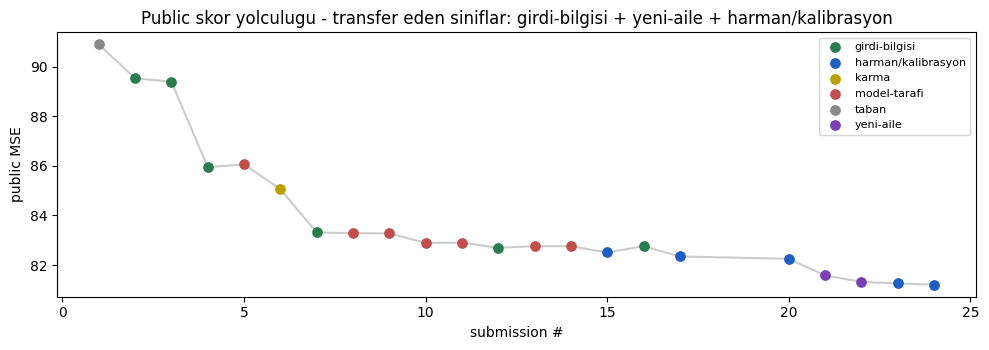

In [12]:
log = pd.DataFrame([
    (1,  "taban (cat+lgb+xgb, uniform)",     90.899, "taban"),
    (2,  "+text_polarity",                   89.528, "girdi-bilgisi"),
    (3,  "+rol/etkilesim FE",                89.393, "girdi-bilgisi"),
    (4,  "+TF-IDF OOF stack",                85.945, "girdi-bilgisi"),
    (5,  "+21-seed",                         86.061, "model-tarafi"),
    (6,  "tune+verdict_tier+stack",          85.059, "karma"),
    (7,  "+yil-etkilesim +FT uyesi",         83.316, "girdi-bilgisi"),
    (8,  "derin-tune",                       83.287, "model-tarafi"),
    (9,  "21-seed robust",                   83.277, "model-tarafi"),
    (10, "+pseudo P1 w0.3 +BERTurk",         82.892, "model-tarafi"),
    (11, "pseudo w0.4 (FAIL)",               82.905, "model-tarafi"),
    (12, "+rol-boost parmak izi +winners",   82.698, "girdi-bilgisi"),
    (13, "re-tune (FAIL)",                   82.765, "model-tarafi"),
    (14, "+3 yeni uye (FAIL)",               82.761, "model-tarafi"),
    (15, "4-sub esit harman",                82.508, "harman/kalibrasyon"),
    (16, "pooled freq (probe, transfer~0)",  82.762, "girdi-bilgisi"),
    (17, "kesin-ozdeslik QP harmani",        82.347, "harman/kalibrasyon"),
    (20, "moment-affine kalibrasyon",        82.252, "harman/kalibrasyon"),
    (21, "+TabPFN-v2 (yeni aile, v12)",      81.584, "yeni-aile"),
    (22, "+krr +knnfeat (cesitlilik, v15)",  81.321, "yeni-aile"),
    (23, "QP-13 kesin-ozdeslik harman",      81.260, "harman/kalibrasyon"),
    (24, "SUB_qpfinal (QP-15 + moment)",     81.209, "harman/kalibrasyon"),
], columns=["sub", "icerik", "public_mse", "sinif"])
print(log.to_string(index=False))
print("\nnot: sub18/19 sabit-deger moment probelaridir (530.07 / 469.66) - grafige dahil edilmedi.")
print("gun-5/6 platosu yeni SINYAL ile degil yeni TAHMINCI AILESI (yeni-aile) ile kirildi; bkz. §5.")

fig, ax = plt.subplots(figsize=(10, 3.6))
colors = {"girdi-bilgisi": "#2a7d4f", "model-tarafi": "#c0504d", "harman/kalibrasyon": "#1f5fbf",
          "yeni-aile": "#7a3fb5", "taban": "#888888", "karma": "#b8a000"}
ax.plot(log["sub"], log["public_mse"], "-", color="#cccccc", zorder=1)
for cl, g in log.groupby("sinif"):
    ax.scatter(g["sub"], g["public_mse"], color=colors[cl], label=cl, zorder=2, s=45)
ax.set_xlabel("submission #"); ax.set_ylabel("public MSE"); ax.legend(fontsize=8)
ax.set_title("Public skor yolculugu - transfer eden siniflar: girdi-bilgisi + yeni-aile + harman/kalibrasyon")
plt.tight_layout(); plt.show()

## 8. Sonuç ve Final Seçimi

### Kanıtlanmış lever'ların bilançosu (public MSE katkısı)

| Lever | Sınıf | Board etkisi |
|---|---|---|
| TF-IDF OOF metin stack'i | girdi-bilgisi | **−3.45** |
| Yıl-etkileşim feature'ları + ilk FT metin üyesi | girdi-bilgisi | **−1.74** |
| Forward-kapılı tune + verdict_tier + stack | karma | −0.89 |
| **TabPFN-v2 (in-context Bayesian), v12** | yeni-aile | **−0.67** (sub20'den v12'ye) |
| **krr + kNN-feat çeşitliliği + QP/affine final zinciri** | yeni-aile / harman | **−0.37** (v12'den qpfinal'e) |
| Pseudo-labeling P1 (w=0.3) + BERTurk üyesi | model-tarafı | −0.38 |
| Üreteç rol-boost parmak izi + winners paketi | girdi-bilgisi | −0.19 |
| Board-doğrulamalı eşit harman | harman/kalibrasyon | −0.19 |
| Kesin-özdeşlik QP harmanı (15 CSV'den qpfinal'e) | harman/kalibrasyon | −0.16 |
| Moment-kurtarımlı affine kalibrasyon | harman/kalibrasyon | −0.10 |

Dört sütunlu bir çözüm: **(1)** üreteci anlamak (tersine mühendislik, yani girdi-bilgisi feature'ları),
**(2)** Türkçe metni ciddiye almak (fine-tune merdiveni, en güçlü tekil sinyal),
**(3)** tahminci çeşitliliği (ortogonal aileler, sinyal tükendiğinde kazanç buradan geldi),
**(4)** ölçümü ciddiye almak (winner's-curse disiplini + kapalı-form board matematiği).

### Final seçimi (2 hak), gerçekleşen

Strateji: **bir "en iyi" + bir "ayrışık sigorta"**:
- **(a) `SUB_qpfinal`**, 15 board CSV'si üzerine kesin-özdeşlik QP harmanı + moment kalibrasyon (§6).
  Public **81.209** (yarış-içi #10), private **81.632**; **bu submission bizi #4 yaptı.**
- **(b) `BLEND_top4_eq`**, qpfinal ile korelasyonu yalnızca **0.997** olan ayrışık 4'lü eşit harman; public
  gürültüsüne ve shake'e karşı düşük-varyans sigorta (private 83.17, devreye girmedi ama downside koruması).

Seçim üreteç-klonu simülatörüyle (`src/48_generator_sim.py`) P(private'ta en iyi) ve **ayrışıklık** kriterine göre
yapıldı. Default "en iyi 2 public" tuzağından (qpfinal + qp13_affine = 0.9998 kopya = sahte hedge) bilinçle kaçınıldı.

### Sonuç

**🏆 Private #4 / 579, MSE 81.6322** (`SUB_qpfinal`). public #15'ten private #4'e (+11 sıra).
Ayrıntılı shake doğrulaması ve kalibrasyonun private'a transfer kanıtı için **§9**.

### Tekrarlanabilirlik haritası

| Adım | Kod | Çıktı |
|---|---|---|
| Feature üretimi | `src/features.py` (cfg bayrakları) |, |
| GBDT tune + build | `src/20_tune.py`, `src/21_build_tuned.py` | `reports/tuned_*` |
| Metin üyeleri | `src/40_local_ft.py`, `src/59_t4_members.py`, `src/60_svr_member.py`, `kernels/d26-text-*` | `reports/*_member_*.npy` |
| **TabPFN-v2 üyesi** | `src/66_tabdl_members.py` (Kaggle T4 `t4_tabpfn` çıktısı) | `reports/tabpfn_member_*.npy` |
| **krr / kNN-feat üyeleri** | `src/73_diverse_combo.py` | `reports/{krr,knnfeat}_member_*.npy` |
| Pseudo-labeling | `src/37_pseudo.py` | `reports/tuned_*_ps*` |
| Stack | `src/30_stack.py` | `submissions/stack_*_blend.csv` |
| Harman + kalibrasyon | `src/49d_sub17_qp.py`, `src/61_probe_math.py`, `src/63_ls_machine.py` | `submissions/frozen/SUB_qpfinal.csv` |
| Kanonik kayıt | `docs/SUBMISSIONS_LOG.md`, `submissions/frozen/` |, |

## 9. Private Sonuç ve Shake Doğrulaması

Yarışma kapanışında (2026-06-15) private leaderboard açıklandı.

> **🏆 BİZ: Private #4 / 579, MSE 81.6322** (`SUB_qpfinal`; final-snapshot public #15).

### Temiz model shake'i kazandı
Sahanın ortalama public'ten private'a kayma **+0.745**; bizimki **+0.423**, yarısı kadar. Public'i ezberlemeyen
model gizli private kümede daha sağlam kaldı; **public #15'ten private #4'e, +11 sıra.** Public lideri
strawveri (public #1, 80.33) overfit yüzünden private #6'ya (+1.39, sahanın en sert düşüşü) çakıldı; yeni
şampiyon OurCraft public'ten private'a **−0.17** ile o da temiz bir model.

| Priv# | Takım | Private | Public | Kayma |
|---|---|---|---|---|
| 1 | OurCraft | 80.343 | 80.518 | −0.17 |
| 2 | AhmedberaT Ozer | 81.143 | 80.966 | +0.18 |
| 3 | Furkan Köksalan | 81.476 | 80.466 | +1.01 |
| **4** | **BİZ (Ahmet Abdullah Gültekin)** | **81.632** | **81.209** | **+0.42** |
| 5 | KazAI | 81.703 | 80.917 | +0.79 |
| 6 | strawveri (public #1) | 81.720 | 80.332 | +1.39 |
| 7 | Bertan Sezgin | 81.866 | 80.881 | +0.99 |
| 8 | Claudia | 81.876 | 81.435 | +0.44 |
| 9 | OzanM. | 81.994 | 81.563 | +0.43 |
| 10 | YaŞaMıM | 82.064 | 80.604 | +1.46 |

### Kalibrasyon public-ezberi DEĞİLDİ, private'a transfer etti
§6'daki QP-harman + moment kalibrasyonun gerçek değer kattığının kanıtı, kendi submission'larımızın private
skorlarında: **ham stack'ler** private'ta 81.77–81.79, kalibre edilmiş **`SUB_qpfinal`** ise **81.63** , 
~0.15 MSE daha iyi. Yani kalibrasyon yalnızca public'i değil **gizli private'ı da** iyileştirdi (gaming değil,
dağılımsal düzeltmenin genellemesi). Aşağıdaki hücre bu karşılaştırmayı kendi içinde (Kaggle'dan alınan
kapanış skorlarıyla) yeniden üretir.

In [13]:
# Kendi submission'larimizin public/private skorlari (Kaggle, kapanis sonrasi - 2026-06-15)
our = pd.DataFrame([
    ("SUB_qpfinal  (sectik #1)",   81.209, 81.632, "QP-15 + moment  <- bizi #4 yapan"),
    ("SUB_eracal   (sec.degil)",   81.222, 81.616, "per-era affine (private en iyi, sira yine #4)"),
    ("SUB_qp13_affine",            81.217, 81.646, "moment-affine"),
    ("stack_v16",                  81.349, 81.673, "ham stack + mpnet (mpnet transfer etmedi)"),
    ("stack_v15 (ham)",            81.321, 81.774, "QP zincirine giren ham stack (krr/knn)"),
    ("stack_v12 (ham)",            81.584, 81.793, "QP zincirine giren ham stack (TabPFN)"),
    ("BLEND_top4  (sectik #2)",    82.508, 83.170, "ayrisik sigorta (devreye girmedi)"),
], columns=["submission", "public", "private", "not"])
our["shift"] = (our["private"] - our["public"]).round(3)
print(our.to_string(index=False))
print()
calib = float(our.loc[our["submission"].str.startswith("SUB_qpfinal"), "private"].iloc[0])
v12 = float(our.loc[our["submission"].str.contains("v12"), "private"].iloc[0])
v15 = float(our.loc[our["submission"].str.contains("v15"), "private"].iloc[0])
print(f"kalibre SUB_qpfinal private {calib:.3f}  vs  QP zincirine giren ham stackler:")
print(f"   stack_v12 {v12:.3f} ({v12 - calib:+.3f})   stack_v15 {v15:.3f} ({v15 - calib:+.3f})")
print(f"   -> QP-harman + moment ham stackleri private da ~{((v12 + v15) / 2 - calib):.2f} MSE GECTI")
print("   -> public-ezberi degil; dagilimsal duzeltme gizli private a da transfer etti.")
print()
print("saha ort. public->private kaymasi +0.745 | bizim kayma +0.423")
print("   -> temiz-model shake avantaji -> public #15 -> PRIVATE #4 / 579.")


              submission  public  private                                           not  shift
SUB_qpfinal  (sectik #1)  81.209   81.632              QP-15 + moment  <- bizi #4 yapan  0.423
SUB_eracal   (sec.degil)  81.222   81.616 per-era affine (private en iyi, sira yine #4)  0.394
         SUB_qp13_affine  81.217   81.646                                 moment-affine  0.429
               stack_v16  81.349   81.673     ham stack + mpnet (mpnet transfer etmedi)  0.324
         stack_v15 (ham)  81.321   81.774        QP zincirine giren ham stack (krr/knn)  0.453
         stack_v12 (ham)  81.584   81.793         QP zincirine giren ham stack (TabPFN)  0.209
 BLEND_top4  (sectik #2)  82.508   83.170             ayrisik sigorta (devreye girmedi)  0.662

kalibre SUB_qpfinal private 81.632  vs  QP zincirine giren ham stackler:
   stack_v12 81.793 (+0.161)   stack_v15 81.774 (+0.142)
   -> QP-harman + moment ham stackleri private da ~0.15 MSE GECTI
   -> public-ezberi degil; dagilimsal duzel